# PyTorch Custom Datasets

How do you get your own data into PyTorch?
One of the ways to do so is: custom datasets.

## Importing PyTorch & Setting up Device Agnostic Code

In [36]:
import torch
from torch import nn
import numpy as np
import matplotlib.pyplot as plt



torch.__version__

'2.5.1+cu121'

In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [38]:
!nvidia-smi

Sat Jul 12 23:27:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.169                Driver Version: 570.169        CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650        Off |   00000000:01:00.0 Off |                  N/A |
| N/A   41C    P8              3W /   50W |     143MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Get Data

Our dataset is a subset of Food101 dataset.

Food101 starts with 101 different classes of food and 1000 images per class (750 training & 250 testing).

Our dataset starts with 3 different classes of food and only 10% of the images (75 training, 25 testing).

Why do this?

When starting out ML projects, it's important to try things on a small scale and then increase the scale when necessary.

The whole point is to speed up how fast you can experiment.

In [39]:
import requests
import zipfile
from pathlib import Path

# setup path to a data folder
data_path = Path("image_data/")
image_path = data_path / "pizza_steak_sushi"

# if the folde doesn't exist, download it and prepare it
if image_path.is_dir():
    print(f"{image_path} directory already exists....skipping download")
else:
    print(f"{image_path} doesn't exist, creating one.....")

    image_path.mkdir(parents = True, exist_ok = True)


    # download the data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading the pizza, steak, sushi data....")

        f.write(request.content)


    # unzip the file
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("unzipping the data....")
        zip_ref.extractall(image_path)

image_data/pizza_steak_sushi directory already exists....skipping download


## Data Preparation & Data Exploration

In [40]:
import os

def walk_through_dir(dir_path):
    """Walks through dir_path returning its contents."""

    for dirpath, dirnames, filenames in os.walk(dir_path):
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}.")

In [41]:
walk_through_dir(image_path)

There are 2 directories and 0 images in image_data/pizza_steak_sushi.
There are 3 directories and 0 images in image_data/pizza_steak_sushi/test.
There are 0 directories and 25 images in image_data/pizza_steak_sushi/test/pizza.
There are 0 directories and 19 images in image_data/pizza_steak_sushi/test/steak.
There are 0 directories and 31 images in image_data/pizza_steak_sushi/test/sushi.
There are 3 directories and 0 images in image_data/pizza_steak_sushi/train.
There are 0 directories and 78 images in image_data/pizza_steak_sushi/train/pizza.
There are 0 directories and 75 images in image_data/pizza_steak_sushi/train/steak.
There are 0 directories and 72 images in image_data/pizza_steak_sushi/train/sushi.


In [42]:
# setup train & testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(PosixPath('image_data/pizza_steak_sushi/train'),
 PosixPath('image_data/pizza_steak_sushi/test'))

### Visualizing the Image

Let's write code to:

1. Get all of the image paths.
2. Pick a random image path using Python's `random.choice()`.
3. Get the image class name using Python's `pathlib.Path.parent.stem`.
4. Open the image with Python's PIL.
5. Show the image and print the metadata.

image_data/pizza_steak_sushi/test/sushi/2394442.jpg
sushi


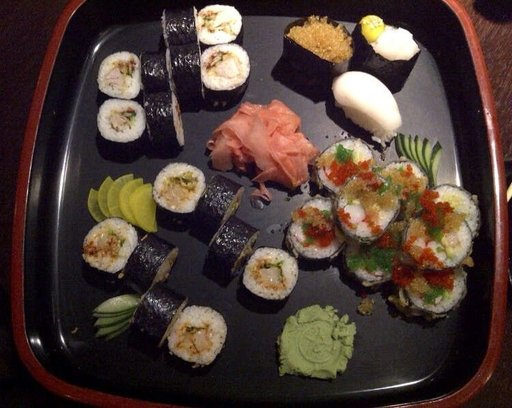

In [43]:
import random
from PIL import Image

random.seed(42)

# get all the images path
image_path_list = list(image_path.glob("*/*/*.jpg"))

# pick a random image path
random_image_path = random.choice(image_path_list)
print(random_image_path)

# get the image class from the path name
image_class = random_image_path.parent.stem
print(image_class)

# open the image
img = Image.open(random_image_path)
img

In [44]:
# turn the image into numpy array
image_as_array = np.asarray(img)
image_as_array

array([[[33, 13, 15],
        [30, 10, 12],
        [30, 10, 12],
        ...,
        [23, 14, 19],
        [21, 12, 17],
        [20, 11, 16]],

       [[35, 15, 17],
        [32, 12, 14],
        [31, 11, 13],
        ...,
        [21, 12, 17],
        [19, 10, 15],
        [19, 10, 15]],

       [[34, 15, 17],
        [31, 12, 14],
        [30, 11, 13],
        ...,
        [19,  9, 17],
        [18,  8, 16],
        [18,  8, 16]],

       ...,

       [[11,  6, 12],
        [11,  6, 12],
        [11,  6, 12],
        ...,
        [33, 19, 18],
        [33, 19, 19],
        [31, 17, 17]],

       [[ 8,  3,  9],
        [ 9,  4, 10],
        [ 9,  4, 10],
        ...,
        [36, 21, 18],
        [32, 16, 16],
        [27, 11, 11]],

       [[ 4,  0,  5],
        [ 5,  0,  6],
        [ 6,  1,  7],
        ...,
        [36, 21, 18],
        [32, 16, 16],
        [25,  9,  9]]], dtype=uint8)

## Transforming Data

Before we can use our image data with PyTorch:

1. Turn your target data into tensors (numerical representation of our images)
2. Turn it into `torch.utils.data.Dataset` & and subsequently a `torch.utils.data.dataLoader` 

### Transforming Data With `torchvision.transforms`

In [45]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [46]:
# write a transform for image
data_transform = transforms.Compose([
    # resize the image to 64x64
    transforms.Resize(size=(64, 64)),

    # flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5),

    # turn the image into tensor
    transforms.ToTensor()
])

In [47]:
data_transform(img)

tensor([[[0.0824, 0.0824, 0.0863,  ..., 0.1412, 0.1373, 0.1294],
         [0.0902, 0.0902, 0.0902,  ..., 0.1412, 0.1373, 0.1255],
         [0.1137, 0.0980, 0.1059,  ..., 0.1333, 0.1412, 0.1294],
         ...,
         [0.1412, 0.1373, 0.1294,  ..., 0.0157, 0.0196, 0.0157],
         [0.1333, 0.1373, 0.1255,  ..., 0.0275, 0.0275, 0.0275],
         [0.1255, 0.1294, 0.1137,  ..., 0.0275, 0.0314, 0.0314]],

        [[0.0431, 0.0431, 0.0392,  ..., 0.0667, 0.0588, 0.0588],
         [0.0353, 0.0431, 0.0392,  ..., 0.0667, 0.0549, 0.0588],
         [0.0392, 0.0471, 0.0471,  ..., 0.0627, 0.0627, 0.0510],
         ...,
         [0.0667, 0.0667, 0.0667,  ..., 0.0078, 0.0078, 0.0039],
         [0.0667, 0.0706, 0.0706,  ..., 0.0118, 0.0118, 0.0118],
         [0.0667, 0.0667, 0.0667,  ..., 0.0196, 0.0157, 0.0118]],

        [[0.0745, 0.0706, 0.0706,  ..., 0.0667, 0.0667, 0.0667],
         [0.0863, 0.0902, 0.0941,  ..., 0.0863, 0.0784, 0.0784],
         [0.1137, 0.1059, 0.0941,  ..., 0.0941, 0.0863, 0.

In [48]:
def plot_transformed_images(image_paths, transform, n = 3, seed = None):
    if seed:
        random.seed(seed)

    random_image_paths = random.sample(image_paths, k = n)

    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows = 1, ncols = 2)
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize: {f.size}")
            ax[0].axis(False)

            # tranform and plot the target image
            tranformed_image = transform(f).permute(1, 2, 0)
            ax[1].imshow(tranformed_image)
            ax[1].set_title(f"Tranformed\nSize: {tranformed_image.shape}")
            ax[1].axis(False)

    

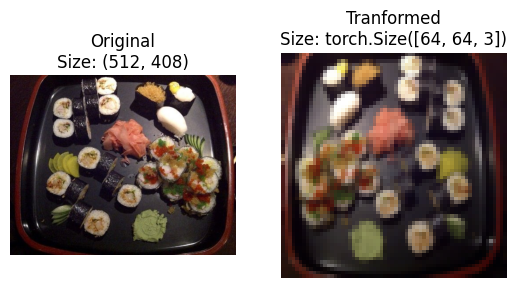

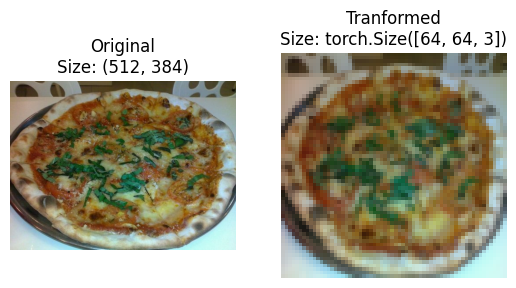

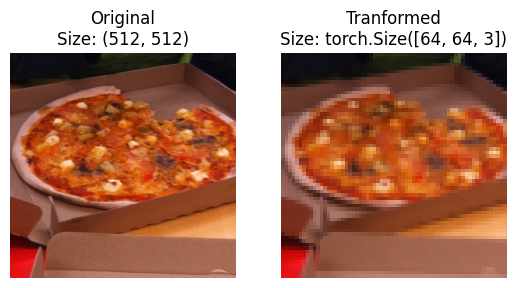

In [49]:
plot_transformed_images(image_paths = image_path_list,
                       transform = data_transform,
                       n = 3,
                       seed = 42)

### Load Image Data Using `ImgaeFolder`

In [50]:
# use Imagefolder to create datasets
from torchvision import datasets

train_data = datasets.ImageFolder(root = train_dir,
                                  transform = data_transform,  # transform for the data
                                  target_transform = None)   # transform for data/target

test_data = datasets.ImageFolder(root = test_dir,
                                 transform = data_transform)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: image_data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: image_data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [51]:
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [52]:
img, label = train_data[0]
img, label

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

### Create a DataLoader


In [53]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data,
                              shuffle = True,
                              batch_size = BATCH_SIZE)

test_dataloader = DataLoader(dataset = test_data,
                             shuffle = False,
                             batch_size = BATCH_SIZE)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x77b13040e6c0>,
 <torch.utils.data.dataloader.DataLoader at 0x77b13040c110>)

In [54]:
len(train_dataloader), len(test_dataloader)

(8, 3)

## Data Augmentation

It's the process of artificially adding diversity to your training data.

In the case of image data, this may mean applying various transformation on training images.

In [55]:
train_transform = transforms.Compose([
    transforms.Resize(size = (224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins = 31),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize(size = ((224, 224))),
    transforms.ToTensor()
])

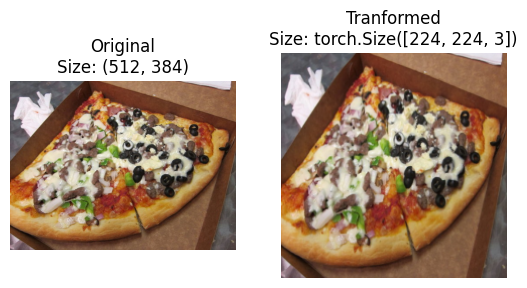

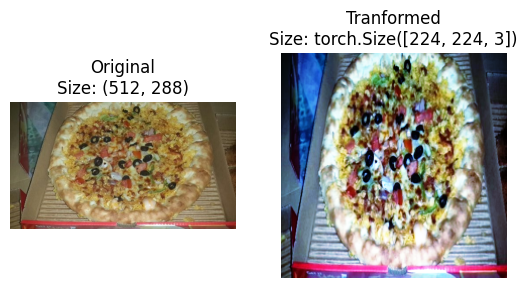

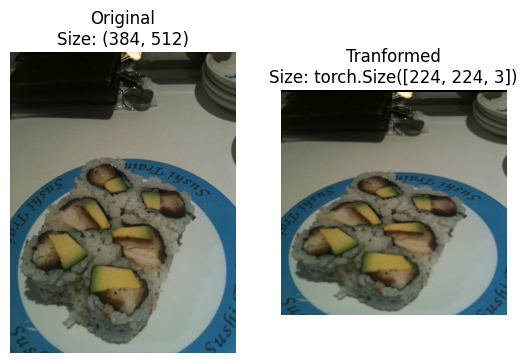

In [56]:
plot_transformed_images(image_paths=image_path_list,
                        transform = train_transform,
                        n = 3)

## Model 0: TinyVGG Without Data Augmentation

### Creating Transforms & Loading The Data For Model 0

In [57]:
# create transform
simple_transform = transforms.Compose([
    transforms.Resize(size = (64, 64)),
    transforms.ToTensor()
])

In [58]:
# load the images
train_data_simple = datasets.ImageFolder(root = train_dir,
                                         transform = simple_transform)

test_data_simple = datasets.ImageFolder(root = test_dir,
                                        transform = simple_transform)


train_data_simple, test_data_simple

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: image_data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: image_data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
            ))

In [59]:
# create dataloader


NUM_WORKERS = os.cpu_count()
SAFE_NUM_WORKERS = NUM_WORKERS - 5

train_dataloader_simple = DataLoader(dataset = train_data_simple,
                                     shuffle = True,
                                     batch_size = BATCH_SIZE,
                                     num_workers = SAFE_NUM_WORKERS)


test_dataloader_simple = DataLoader(dataset = test_data_simple,
                                    batch_size = BATCH_SIZE,
                                    shuffle = False,
                                    num_workers = SAFE_NUM_WORKERS)


train_dataloader_simple, test_dataloader_simple

(<torch.utils.data.dataloader.DataLoader at 0x77b120181fd0>,
 <torch.utils.data.dataloader.DataLoader at 0x77b123df80b0>)

### Create TinyVGG Model Class


In [60]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels = input_shape,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 0),
            
            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 0),

            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )

        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 0),

            nn.ReLU(),
            nn.Conv2d(in_channels = hidden_units,
                      out_channels = hidden_units,
                      kernel_size = 3,
                      stride = 1,
                      padding = 0),

            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units * 13 * 13,
                      out_features = output_shape)
        )

    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

In [61]:
torch.manual_seed(42)

model_0 = TinyVGG(input_shape = 3,
                  hidden_units = 10,
                  output_shape = len(class_names)).to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### Try a Forward Pass To Troubleshoot

In [62]:
# get a single image
image_batch, label_batch = next(iter(train_dataloader_simple))

model_0(image_batch.to(device))

tensor([[ 2.0795e-02, -1.9510e-03,  9.5212e-03],
        [ 1.8440e-02,  2.4669e-03,  6.6609e-03],
        [ 1.7695e-02,  1.0282e-03,  9.4975e-03],
        [ 2.4446e-02, -3.3489e-03,  9.5877e-03],
        [ 1.9939e-02,  6.9130e-04,  1.0778e-02],
        [ 2.1281e-02,  2.0434e-03,  5.0046e-03],
        [ 2.0996e-02,  1.6417e-04,  1.2481e-02],
        [ 2.1566e-02, -1.9607e-03,  9.7175e-03],
        [ 2.4500e-02, -4.7904e-03,  8.5394e-03],
        [ 2.0239e-02, -4.7980e-04,  1.0907e-02],
        [ 2.2219e-02, -4.1815e-04,  9.8173e-03],
        [ 2.2318e-02, -2.1642e-03,  9.4428e-03],
        [ 2.1851e-02, -3.7225e-03,  8.3784e-03],
        [ 2.2881e-02, -1.7559e-03,  1.0299e-02],
        [ 2.1635e-02, -4.3994e-03,  9.4990e-03],
        [ 2.2101e-02, -4.1470e-03,  9.3904e-03],
        [ 2.1226e-02, -4.4215e-03,  1.1476e-02],
        [ 2.1698e-02, -2.7458e-03,  8.4966e-03],
        [ 1.9974e-02, -3.3062e-07,  8.4496e-03],
        [ 1.8308e-02,  1.6378e-03,  8.5491e-03],
        [ 2.0768e-02

### Use `torchinfo` To Get The Info Of The Model

In [ ]:
from torchinfo import summary